# VAR Parameter Estimation

The Vector Auto Regressive Process is a generalization of the single variable Autoregressive (AR) process to multiple variables. The $\text{VAR}(n)$ </br> 
is defined by,

$
\begin{align}
X_t = \mathcal{M} + \Phi_1 X_{t-1} \Phi_2 X_{t-2} + \cdots + \Phi_n X_{t-n} + \mathcal{E}_t
\end{align}
\tag{1}
$

where $t = 1, 2, 3, \ldots, T$, $X_t$ is column vector of length $m$ representing the time series, $\mathcal{M}$ is a $m$ element constant offset column vector, $\Phi_t$ are $m \times m$ matrices denoting constant coefficients and $\mathcal{E}_t$ an a random column normal vector with zero mean and covariance matrix $\Omega$,

$
\begin{align}
\mathcal{E}_t \sim \text{Normal}(0, \Omega)
\end{align}
\tag{2}
$

It follows that,

$
\begin{align}
\text{Cov}(\mathcal{E}_t, \mathcal{E}_s) = \Omega 
\end{align}
\tag{3}
$

Given a multivariate time series $X_t$ the following parameters are estimated: $\mathcal{M}$, $\Phi_n$ and $\Omega$. Here simulations are performed for specified values of the parameters and estimation methods the take the simulated $X_t$ as input are tested by comparing the result to the values specified .

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot
import numpy

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import var, stats
from lib.plots import stack, fpoints, fcurve, PlotType

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
def comparison_plot(xt, title, ylim=(-2.5, 2.5), xlim=(0, 1000)):
    ylabels = [f"$S_{i+1}(t)$" for i in range(len(xt))]
    stack(xt, ylim=ylim, xlim=xlim, title=title, ylabels=ylabels, xlabel=r"$t$", figsize=(10, 6), title_offset=0.2, lw=1)

## $\text{VAR}(1)$ Simulations

### Uncoupled $\text{AR}(1)$

In [3]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.0],
                      [0.0, 0.25]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])

npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [4]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

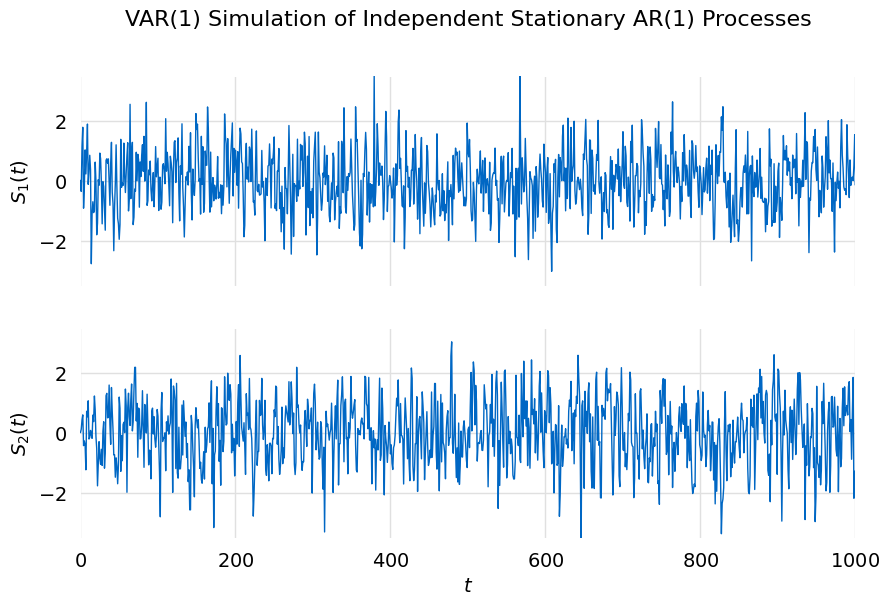

In [5]:
title = f"VAR(1) Simulation of Independent Stationary AR(1) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [6]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 12, Nov, 2023
Time:                     18:42:20
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0138988
Nobs:                     4999.00    HQIC:                0.00881834
Log likelihood:          -14195.7    FPE:                    1.00610
AIC:                   0.00607684    Det(Omega_mle):         1.00489
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.026373         0.014128           -1.867           0.062
L1.y1         0.248212         0.013706           18.110           0.000
L1.y2        -0.001939         0.013604           -0.143           0.887

Results for equation 

In [7]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": -0.02637283858871843,
         "err": 0.014128184970303739,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "3b95b2f4-8314-4857-bd14-d9028dcdff36",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.004164353976620994,
         "err": 0.014210340383987424,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "3b95b2f4-8314-4857-bd14-d9028dcdff36",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 1,
   "_VAREst__params": [
      {
         "est": 0.2482118070087665,
         "err": 0.013705567786684886,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 1

### Coupled $\text{AR}(1)$

In [8]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.05],
                      [0.5, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [9]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

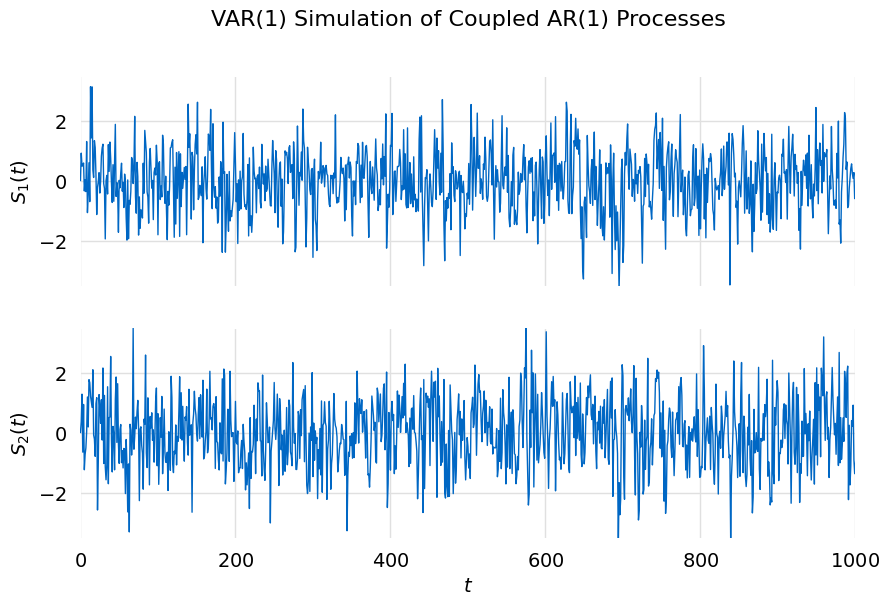

In [10]:
title = f"VAR(1) Simulation of Coupled AR(1) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [11]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 12, Nov, 2023
Time:                     18:42:20
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                -0.00596453
Nobs:                     4999.00    HQIC:                -0.0110450
Log likelihood:          -14146.1    FPE:                   0.986308
AIC:                   -0.0137865    Det(Omega_mle):        0.985125
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.003691         0.013910           -0.265           0.791
L1.y1         0.247617         0.013760           17.995           0.000
L1.y2         0.057748         0.012196            4.735           0.000

Results for equation 

In [12]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": -0.0036907639999942806,
         "err": 0.013910264490020634,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "1c435118-d65d-4662-80dc-f496ed7c0679",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.019667889505910714,
         "err": 0.014281360378413935,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "1c435118-d65d-4662-80dc-f496ed7c0679",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 1,
   "_VAREst__params": [
      {
         "est": 0.24761674241362935,
         "err": 0.013760044750220595,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order"

### Coupled $\text{AR}(1)$ With Non Unit Normal Noise

In [13]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.05],
                      [0.5, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[2.0, 0.2],
                      [0.2, 2.0]])
npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [14]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

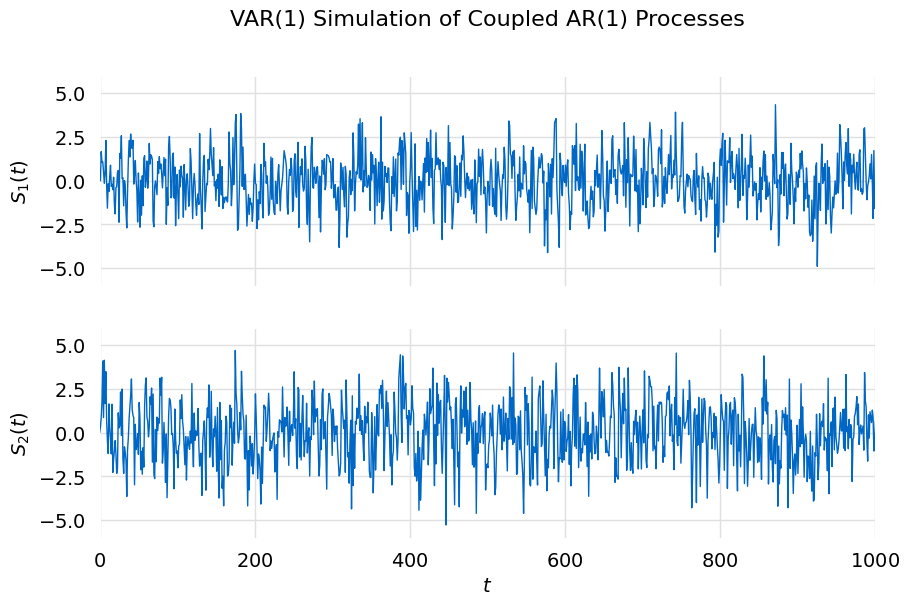

In [15]:
title = f"VAR(1) Simulation of Coupled AR(1) Processes"
comparison_plot(xt, title, ylim=(-6.0, 6.0))

In [16]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 12, Nov, 2023
Time:                     18:42:21
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    1.38655
Nobs:                     4999.00    HQIC:                   1.38147
Log likelihood:          -17626.7    FPE:                    3.96985
AIC:                      1.37873    Det(Omega_mle):         3.96509
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.007946         0.019851            0.400           0.689
L1.y1         0.253171         0.013965           18.129           0.000
L1.y2         0.040615         0.012304            3.301           0.001

Results for equation 

In [17]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": 0.007946432165333072,
         "err": 0.019850825944526564,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "7f509079-eb37-439e-9f22-4ac995096404",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.026876638707799126,
         "err": 0.020167172283883053,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "7f509079-eb37-439e-9f22-4ac995096404",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 1,
   "_VAREst__params": [
      {
         "est": 0.2531708866196825,
         "err": 0.013965100200910088,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 1

## $\text{VAR}(2)$ Simulations
### Uncoupled $\text{AR}(2)$

In [18]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.0],
                      [0.0, 0.25]]),
        numpy.matrix([[0.5, 0.0],
                      [0.0, 0.5]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=2
var.compute_is_stationary(phi)

True

In [19]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

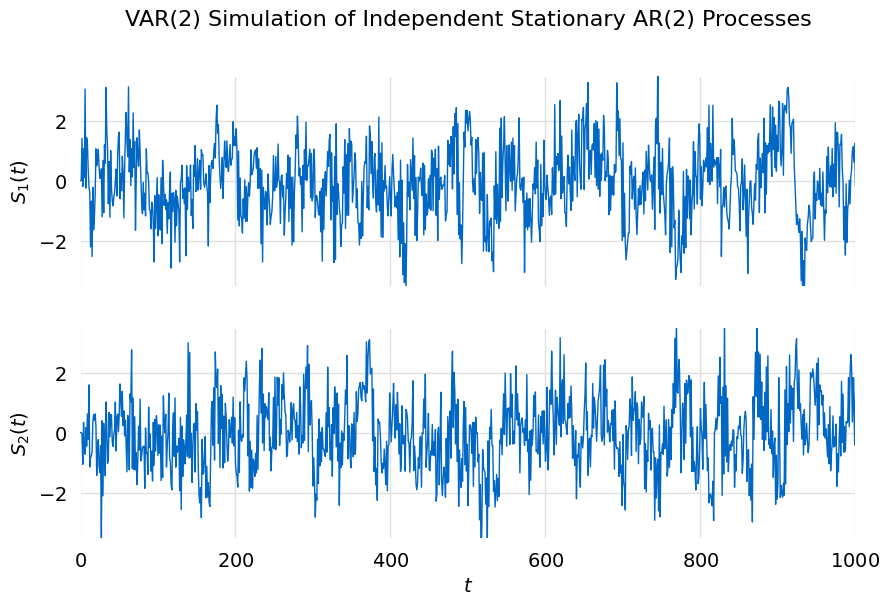

In [20]:
title = f"VAR(2) Simulation of Independent Stationary AR(2) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [21]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 12, Nov, 2023
Time:                     18:42:21
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0442076
Nobs:                     4998.00    HQIC:                 0.0357388
Log likelihood:          -14251.6    FPE:                    1.03166
AIC:                    0.0311688    Det(Omega_mle):         1.02960
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.011008         0.014248           -0.773           0.440
L1.y1         0.244081         0.012250           19.924           0.000
L1.y2        -0.007115         0.012261           -0.580           0.562
L2.y1         0.500305

In [22]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": -0.011008036799272527,
         "err": 0.014248320389116635,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "b0bb564a-a3ed-4d02-8797-b972ab05a03c",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.006778386830734555,
         "err": 0.014276851893431973,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "b0bb564a-a3ed-4d02-8797-b972ab05a03c",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 2,
   "_VAREst__params": [
      {
         "est": 0.24408123477108318,
         "err": 0.012250396883040355,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order":

### Coupled $\text{AR}(2)$

In [23]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.15],
                      [0.1, 0.1]]),
        numpy.matrix([[0.25, 0.3],
                      [0.2, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=2
var.compute_is_stationary(phi)

True

In [24]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

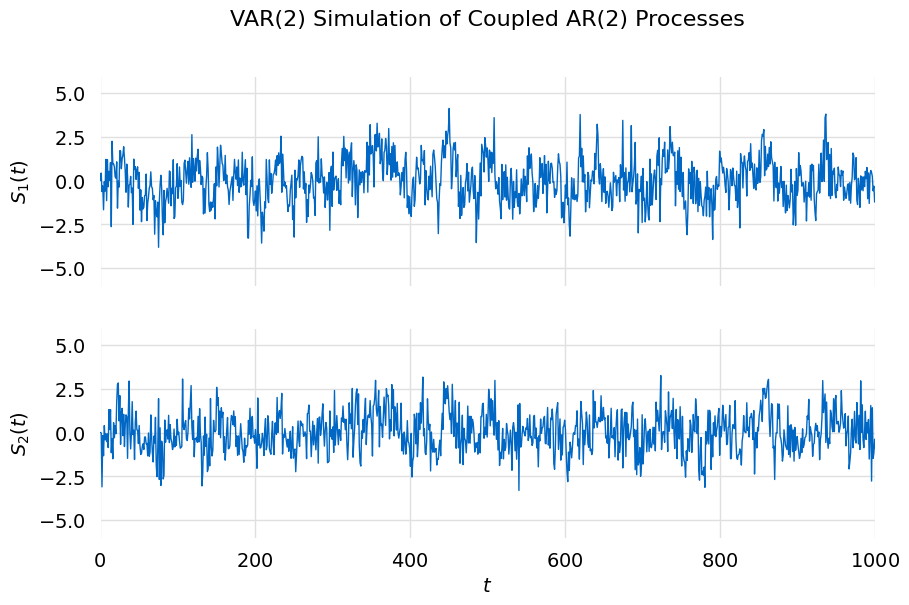

In [25]:
title = f"VAR(2) Simulation of Coupled AR(2) Processes"
comparison_plot(xt, title, ylim=(-6.0, 6.0))

In [26]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 12, Nov, 2023
Time:                     18:42:22
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0724370
Nobs:                     4998.00    HQIC:                 0.0639682
Log likelihood:          -14322.1    FPE:                    1.06120
AIC:                    0.0593982    Det(Omega_mle):         1.05908
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.006130         0.014254            0.430           0.667
L1.y1         0.165163         0.012977           12.727           0.000
L1.y2         0.129848         0.013545            9.587           0.000
L2.y1         0.269082

In [27]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": 0.006130457043582057,
         "err": 0.01425386835773454,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "2217703a-784d-47b1-9099-0ac90c732f0e",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.01160869199741275,
         "err": 0.014469283364056566,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "2217703a-784d-47b1-9099-0ac90c732f0e",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 2,
   "_VAREst__params": [
      {
         "est": 0.16516308332488372,
         "err": 0.012976945960679066,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,


## $\text{VAR}(3)$ Simulations
### Uncoupled $\text{AR}(3)$

In [28]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.0, 0.0],
                      [0.0, 0.15, 0.0],
                      [0.0, 0.0, 0.05]]),
        numpy.matrix([[0.05, 0.0, 0.0],
                      [0.0, 0.1, 0.0],
                      [0.0, 0.0, 0.05]]),
        numpy.matrix([[0.15, 0.0, 0.0],
                      [0.0, 0.15, 0.0],
                      [0.0, 0.0, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])
var.compute_is_stationary(phi)
npts=5000
nlag=3

In [29]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

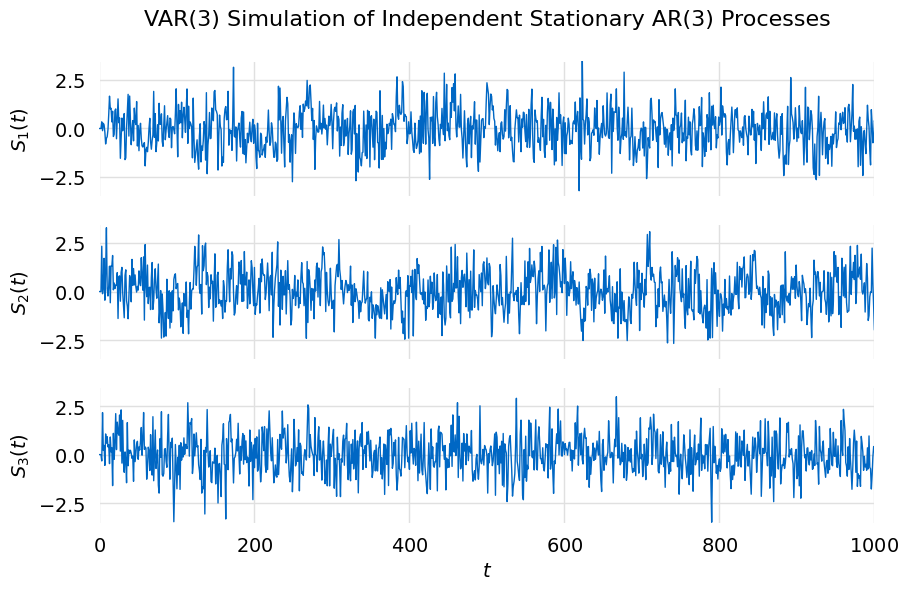

In [30]:
title = f"VAR(3) Simulation of Independent Stationary AR(3) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [31]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 12, Nov, 2023
Time:                     18:42:22
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  0.0326311
Nobs:                     4997.00    HQIC:                0.00722052
Log likelihood:          -21225.1    FPE:                   0.993529
AIC:                  -0.00649190    Det(Omega_mle):        0.987588
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.001681         0.014119           -0.119           0.905
L1.y1         0.147477         0.014064           10.486           0.000
L1.y2         0.009596         0.013813            0.695           0.487
L1.y3         0.025606

In [32]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": -0.001680595037942047,
         "err": 0.014118911898073502,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "8a47080a-12f7-4f16-9822-889ffe7e105f",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.018936561897898437,
         "err": 0.01429229350831796,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "8a47080a-12f7-4f16-9822-889ffe7e105f",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.024763411199196363,
         "err": 0.01404378571195674,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 2,
         "order": 1,
         "est_id": "8a47080a-12f7-4f16-9822-889ffe7e105f

### Coupled $\text{AR}(3)$

In [33]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.1, 0.2],
                      [0.0, 0.15, 0.1],
                      [0.05, 0.025, 0.05]]),
        numpy.matrix([[0.015, 0.01, 0.0],
                      [0.1, 0.1, 0.05],
                      [0.1, 0.05, 0.05]]),
        numpy.matrix([[0.15, 0.05, 0.1],
                      [0.0, 0.15, 0.025],
                      [0.025, 0.15, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])
npts=5000
nlag=11
var.compute_is_stationary(phi)


True

In [34]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

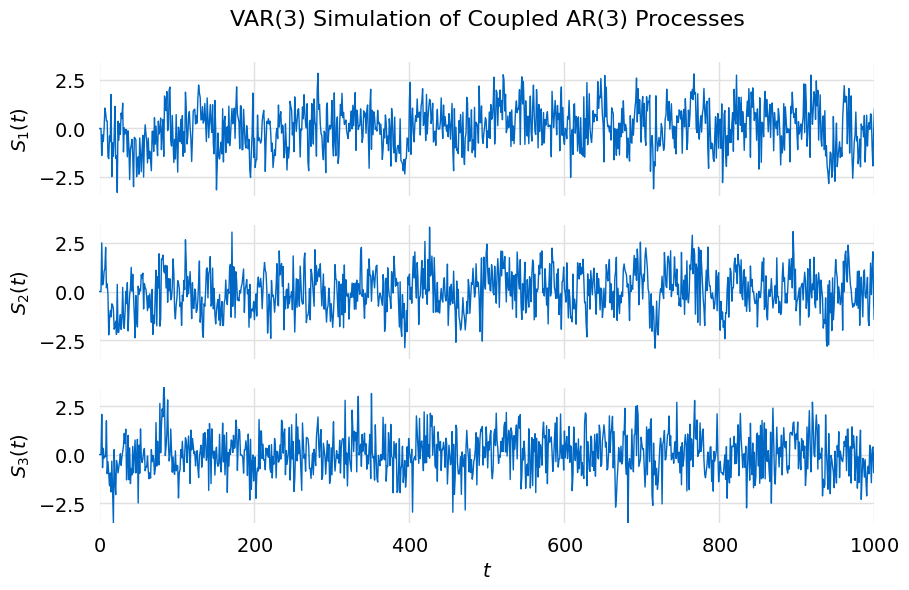

In [35]:
title = f"VAR(3) Simulation of Coupled AR(3) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [36]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 12, Nov, 2023
Time:                     18:42:23
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   0.107568
Nobs:                     4989.00    HQIC:                 0.0210581
Log likelihood:          -21071.3    FPE:                   0.974695
AIC:                   -0.0256312    Det(Omega_mle):        0.955036
--------------------------------------------------------------------
Results for equation y1
            coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------
const          0.016951         0.014049            1.207           0.228
L1.y1          0.133091         0.014208            9.367           0.000
L1.y2          0.095734         0.014058            6.810           0.000
L1.y3          0.

In [37]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": 0.016950507248597833,
         "err": 0.014049059205821576,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "3ae9a928-af7b-438e-b40a-443eccae67be",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.004234816916399736,
         "err": 0.014202103353437858,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "3ae9a928-af7b-438e-b40a-443eccae67be",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.01182242046509922,
         "err": 0.014078750306912675,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 2,
         "order": 1,
         "est_id": "3ae9a928-af7b-438e-b40a-443eccae67be"